In [4]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [5]:
#importing as dataframes
df_elo=pd.read_csv(r"../data/ranking_soccer_1901-2023.csv")
df_matches=pd.read_csv(r"..\data\results.csv")

In [6]:
#fropping duplicates and adding elo_home and elo_away and making a combined dataframe(df_combined)
df_elo_unique = df_elo.drop_duplicates(subset=['team'], keep='last')
df_combined = pd.merge(
    df_matches, 
    df_elo_unique[['team', 'rating']], 
    left_on='home_team', 
    right_on='team', 
    how='left'
).rename(columns={'rating': 'elo_home'}).drop('team', axis=1)
df_combined = pd.merge(
    df_combined, 
    df_elo_unique[['team', 'rating']], 
    left_on='away_team', 
    right_on='team', 
    how='left'
).rename(columns={'rating': 'elo_opp'}).drop('team', axis=1)


In [7]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49287 non-null  object 
 1   home_team   49287 non-null  object 
 2   away_team   49287 non-null  object 
 3   home_score  49215 non-null  float64
 4   away_score  49215 non-null  float64
 5   tournament  49287 non-null  object 
 6   city        49287 non-null  object 
 7   country     49287 non-null  object 
 8   neutral     49287 non-null  bool   
 9   elo_home    46913 non-null  float64
 10  elo_opp     46900 non-null  float64
dtypes: bool(1), float64(4), object(6)
memory usage: 3.8+ MB


In [9]:
#as 5% of the data was of null values I decided to drop the null values 
df_combined = df_combined.dropna(subset=["elo_home", "elo_opp"])
df_combined = df_combined.dropna(subset=["home_score", "away_score"])

In [11]:
#adding coloumns result and elo_diff so that stats can be a bit better
def get_result(row):
    if row["home_score"] > row["away_score"]:
        return 2
    elif row["home_score"] == row["away_score"]:
        return 1
    else:
        return 0

df_combined["result"] = df_combined.apply(get_result, axis=1)
df_combined["elo_diff"] = df_combined["elo_home"] - df_combined["elo_opp"]

In [13]:
#only keeping the important tournaments and dates after the year 1990 and the measure of a friendly match
important_tournaments = [
    "FIFA World Cup",
    "FIFA World Cup qualification",
    "UEFA Euro",
    "UEFA Euro qualification",
    "Copa América",
    "African Cup of Nations",
    "African Cup of Nations qualification",
    "AFC Asian Cup",
    "AFC Asian Cup qualification",
    "Gold Cup",
    "UEFA Nations League",
    "CONCACAF Nations League",
    "Confederations Cup",
    "Oceania Nations Cup",
    "Friendly"
]
df_combined = df_combined[df_combined["tournament"].isin(important_tournaments)]
df_combined["is_friendly"] = (df_combined["tournament"] == "Friendly").astype(int)
df_combined = df_combined[df_combined["date"] >= "1990-01-01"]

In [17]:
#reindexing
df_combined = df_combined.reset_index(drop=True)

In [19]:
df_combined.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,elo_home,elo_opp,result,elo_diff,is_friendly
0,1990-01-12,Algeria,Mali,5.0,0.0,Friendly,Paris,France,True,1726.0,1616.0,2,110.0,1
1,1990-01-14,Algeria,Cameroon,3.0,1.0,Friendly,Paris,France,True,1726.0,1620.0,2,106.0,1
2,1990-01-17,Greece,Belgium,2.0,0.0,Friendly,Athens,Greece,False,1729.0,1990.0,2,-261.0,1
3,1990-01-17,Mexico,Argentina,2.0,0.0,Friendly,Los Angeles,United States,True,1794.0,2138.0,2,-344.0,1
4,1990-01-20,Malawi,Tanzania,2.0,2.0,Friendly,Lobamba,Swaziland,True,1350.0,1351.0,1,-1.0,1


In [23]:
#adding another coloumn of home_advantage in order to see the home advantage
def get_home_advantage(row):
    if row["neutral"] == True:
        return 0
    elif row["home_team"] == row["country"]:
        return 1
    else:
        return -1
df_combined["home_advantage"] = df_combined.apply(get_home_advantage,axis=1)

In [24]:
df_combined.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,elo_home,elo_opp,result,elo_diff,is_friendly,home_advantage
0,1990-01-12,Algeria,Mali,5.0,0.0,Friendly,Paris,France,True,1726.0,1616.0,2,110.0,1,0
1,1990-01-14,Algeria,Cameroon,3.0,1.0,Friendly,Paris,France,True,1726.0,1620.0,2,106.0,1,0
2,1990-01-17,Greece,Belgium,2.0,0.0,Friendly,Athens,Greece,False,1729.0,1990.0,2,-261.0,1,1
3,1990-01-17,Mexico,Argentina,2.0,0.0,Friendly,Los Angeles,United States,True,1794.0,2138.0,2,-344.0,1,0
4,1990-01-20,Malawi,Tanzania,2.0,2.0,Friendly,Lobamba,Swaziland,True,1350.0,1351.0,1,-1.0,1,0


In [68]:
#saving it into csv
df_combined.to_csv("..\data\CombinedData.csv")

In [29]:
df_intvalues=df_combined.select_dtypes(include=["number"])

<Axes: >

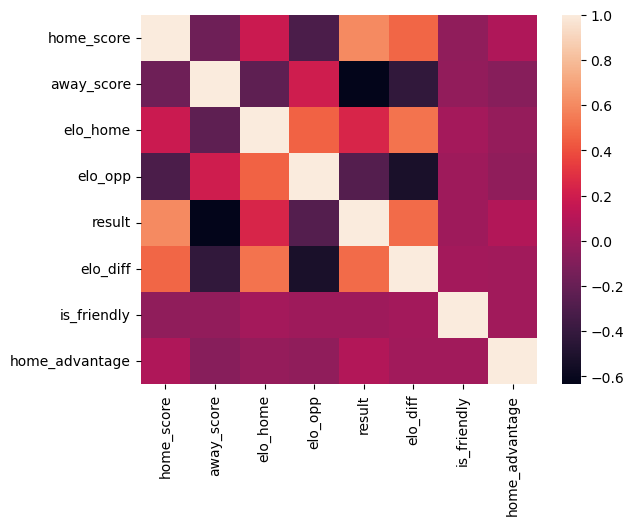

In [31]:
sns.heatmap(df_intvalues.corr())

In [32]:
df_combined=df_combined.sort_values('date')
def calculate_form(team, current_date, df, last_n=5):
    previous_matches = df[
        (
            (df["home_team"] == team) |
            (df["away_team"] == team)
        ) &
        (df["date"] < current_date)
    ].sort_values("date", ascending=False).head(last_n)

    points = 0
    for _, row in previous_matches.iterrows():
        if row["home_team"] == team:

            if row["home_score"] > row["away_score"]:
                points += 3

            elif row["home_score"] == row["away_score"]:
                points += 1
        else:

            if row["away_score"] > row["home_score"]:
                points += 3

            elif row["away_score"] == row["home_score"]:
                points += 1

    return points


In [35]:
df_combined["home_form"] = df_combined.apply(
    lambda row: calculate_form(
        row["home_team"],
        row["date"],
        df_combined
    ),
    axis=1
)

In [42]:
df_combined["away_form"] = df_combined.apply(
    lambda row: calculate_form(
        row["away_team"],
        row["date"],
        df_combined
    ),
    axis=1
)

In [44]:
df_combined.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,elo_home,elo_opp,result,elo_diff,is_friendly,home_advantage,home_form,away_form
0,1990-01-12,Algeria,Mali,5.0,0.0,Friendly,Paris,France,True,1726.0,1616.0,2,110.0,1,0,0,0
1,1990-01-14,Algeria,Cameroon,3.0,1.0,Friendly,Paris,France,True,1726.0,1620.0,2,106.0,1,0,3,0
2,1990-01-17,Greece,Belgium,2.0,0.0,Friendly,Athens,Greece,False,1729.0,1990.0,2,-261.0,1,1,0,0
3,1990-01-17,Mexico,Argentina,2.0,0.0,Friendly,Los Angeles,United States,True,1794.0,2138.0,2,-344.0,1,0,0,0
4,1990-01-20,Malawi,Tanzania,2.0,2.0,Friendly,Lobamba,Swaziland,True,1350.0,1351.0,1,-1.0,1,0,0,0


In [47]:
df_combined.to_csv("..\data\CombinedData.csv")

In [59]:
def get_goal_stats(team, current_date, df, last_n=5):
    previous_matches = df[
        (
            (df["home_team"] == team) |
            (df["away_team"] == team)
        ) &
        (df["date"] < current_date)
    ].sort_values("date", ascending=False).head(last_n)

    goals_scored=[]
    goals_conceded=[]
    for _,row in previous_matches.iterrows():
        if row['home_team']==team:
            goals_scored.append(row["home_score"])
            
            goals_conceded.append(row["away_score"])
        else:
            goals_scored.append(row['away_score'])
            goals_conceded.append(row['home_score'])
    if(len(goals_scored)==0):
        return 0,0
    average_scored=sum(goals_scored)/len(goals_scored)
    average_conceded=sum(goals_conceded)/len(goals_conceded)
    return average_scored,average_conceded
df_combined[['home__avg_goal_scored','home_avg_goal_conceded']]=df_combined.apply(
    lambda row:pd.Series(
        get_goal_stats(
            row['home_team'],
            row['date'],
            df_combined
        )
    ),axis=1
)
df_combined[['away_avg_goal_scored','away_avg_goal_conceded']]=df_combined.apply(
    lambda row:pd.Series(
        get_goal_stats(
            row['away_team'],
            row['date'],
            df_combined
        )
    ),
    axis=1
)

In [66]:
df_combined["home_goal_diff_form"] = (
    df_combined["home__avg_goal_scored"] -
    df_combined["home_avg_goal_conceded"]
)

df_combined["away_goal_diff_form"] = (
    df_combined["away_avg_goal_scored"] -
    df_combined["away_avg_goal_conceded"]
)

In [67]:
df_combined.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,elo_home,...,is_friendly,home_advantage,home_form,away_form,home__avg_goal_scored,home_avg_goal_conceded,away_avg_goal_scored,away_avg_goal_conceded,home_goal_diff_form,away_goal_diff_form
24678,2026-03-31,Ivory Coast,Scotland,1.0,0.0,Friendly,Liverpool,England,True,1644.0,...,1,0,10,9,2.6,1.2,2.2,1.6,1.4,0.6
24679,2026-03-31,Jordan,Nigeria,2.0,2.0,Friendly,Antalya,Turkey,True,1503.0,...,1,0,1,11,1.6,2.6,1.6,0.2,-1.0,1.4
24680,2026-03-31,Mexico,Belgium,1.0,1.0,Friendly,Chicago,United States,True,1794.0,...,1,0,10,11,1.4,0.4,3.4,1.0,1.0,2.4
24674,2026-03-31,England,Japan,0.0,1.0,Friendly,London,England,False,2015.0,...,1,1,13,7,2.6,0.2,1.4,0.6,2.4,0.8
24700,2026-03-31,Kosovo,Turkey,0.0,1.0,FIFA World Cup qualification,Pristina,Kosovo,False,1499.0,...,0,1,11,13,1.6,0.8,3.0,0.8,0.8,2.2


In [75]:
latest_stats = df_combined.sort_values("date").groupby("home_team").tail(1)
latest_stats.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221 entries, 441 to 24700
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    221 non-null    object 
 1   home_team               221 non-null    object 
 2   away_team               221 non-null    object 
 3   home_score              221 non-null    float64
 4   away_score              221 non-null    float64
 5   tournament              221 non-null    object 
 6   city                    221 non-null    object 
 7   country                 221 non-null    object 
 8   neutral                 221 non-null    bool   
 9   elo_home                221 non-null    float64
 10  elo_opp                 221 non-null    float64
 11  result                  221 non-null    int64  
 12  elo_diff                221 non-null    float64
 13  is_friendly             221 non-null    int64  
 14  home_advantage          221 non-null    int